<a href="https://colab.research.google.com/github/fabricejumel/5IRC-2026-2027-CYBER-SIA/blob/main/Attaques_yolov8_EOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Laboratoire d'Attaques Adversariales sur YOLOv8, Expectation Over Transformation

In [21]:
!pip install ultralytics torch torchvision pillow matplotlib opencv-python

In [22]:
import torch
import torchvision.transforms as transforms
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from ultralytics import YOLO
import numpy as np

# Choix du device (CUDA 13 / GPU ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

Utilisation du device : cuda



image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 6.6ms
Speed: 2.3ms preprocess, 6.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


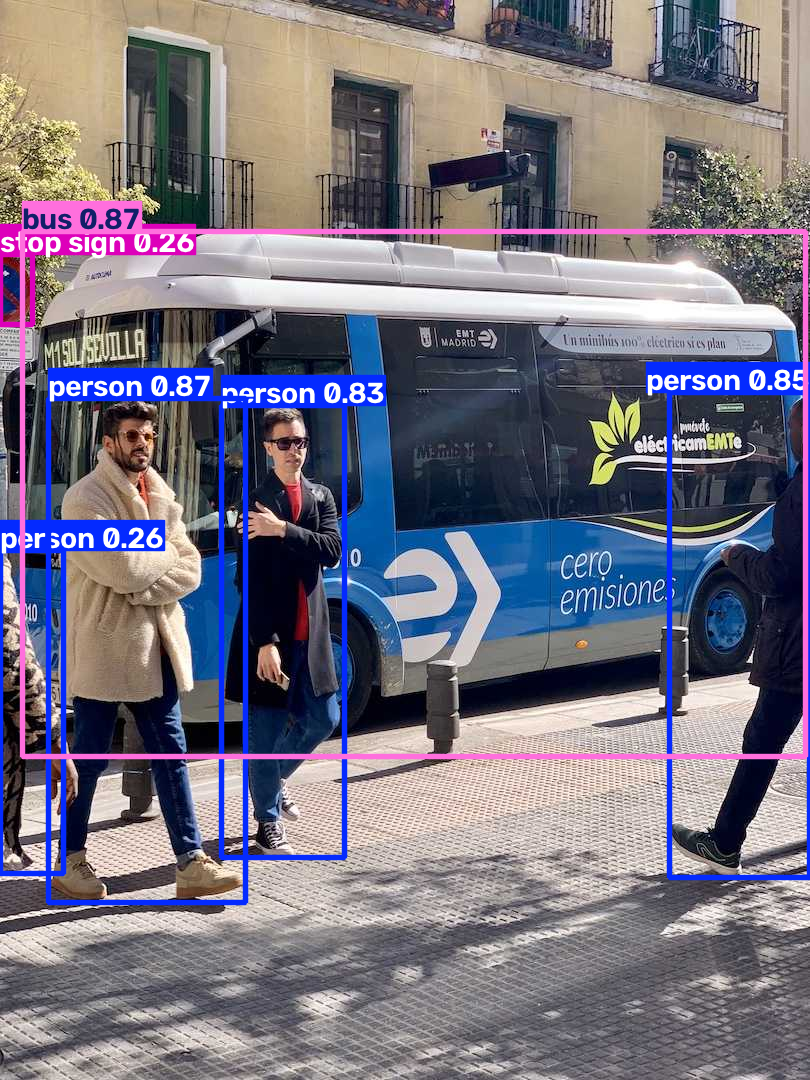

In [28]:
# Chargement du modèle nano pré-entraîné
model = YOLO("yolov8n.pt")
model.model.to(device)

# Téléchargement/Utilisation d'une image de test de COCO8 (ex: un chien ou une personne)
# Ultralytics intègre des images d'exemple, prenons 'bus.jpg' ou 'zidane.jpg' ou une image COCO8
from ultralytics.utils.downloads import safe_download
import os

# Télécharge une image de test classique d'Ultralytics si elle n'existe pas
image_path = "bus.jpg"
if not os.path.exists(image_path):
    safe_download("https://ultralytics.com/images/bus.jpg", dir=".")

# Affichage de la prédiction propre d'origine sur l'image
results = model(image_path)
results[0].show() # Ouvre l'image avec les bounding boxes d'origine

In [29]:
def apply_patch(image_path, patch_tensor, patch_coords=(100, 100, 150, 150)):
    """
    Colle un patch de pixels (patch_tensor) sur l'image originale
    aux coordonnées (x_min, y_min, x_max, y_max).
    """
    pil_img = Image.open(image_path).convert("RGB")

    # Transformation en tenseur [3, H, W] entre 0 et 1
    to_tensor = transforms.ToTensor()
    to_pil = transforms.ToPILImage()

    img_tensor = to_tensor(pil_img).to(device)

    x_min, y_min, x_max, y_max = patch_coords

    # On s'assure que le patch_tensor a la bonne taille (H_patch, W_patch)
    # et on l'incruste sur l'image
    img_tensor[:, y_min:y_max, x_min:x_max] = patch_tensor

    # Retourne l'image modifiée au format PIL
    return to_pil(img_tensor.cpu())

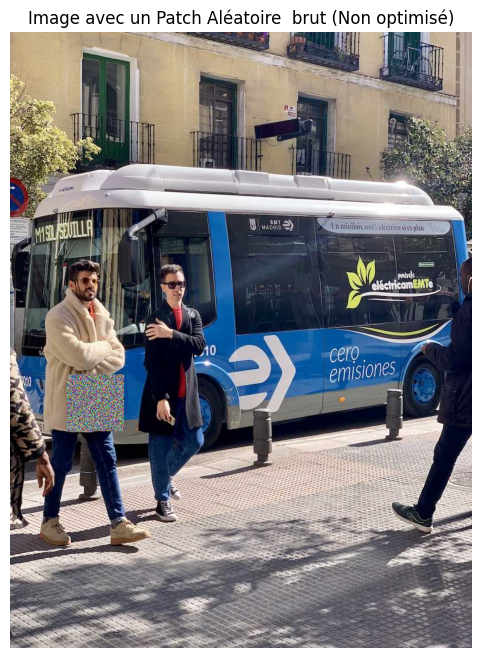

In [30]:
# Définition de la taille de notre patch (ex: un carré de 100x100 pixels)
patch_h, patch_w = 100, 100
x=100
y=600
patch_coords = (x, y, x + patch_w, y + patch_h) # (x_min, y_min, x_max, y_max)

# Création d'un patch de bruit initial (aléatoire ou gris à 0.5)
# En mode optimisation, ce tenseur aura requires_grad=True
adversarial_patch = torch.rand(3, patch_h, patch_w, device=device)

# Application sur l'image
modified_image = apply_patch(image_path, adversarial_patch, patch_coords)

# Visualisation rapide
plt.figure(figsize=(8, 8))
plt.imshow(modified_image)
plt.axis("off")
plt.title("Image avec un Patch Aléatoire  brut (Non optimisé)")
plt.show()


image 1/1 /content/temp_patched_image.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 8.0ms
Speed: 2.8ms preprocess, 8.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 480)


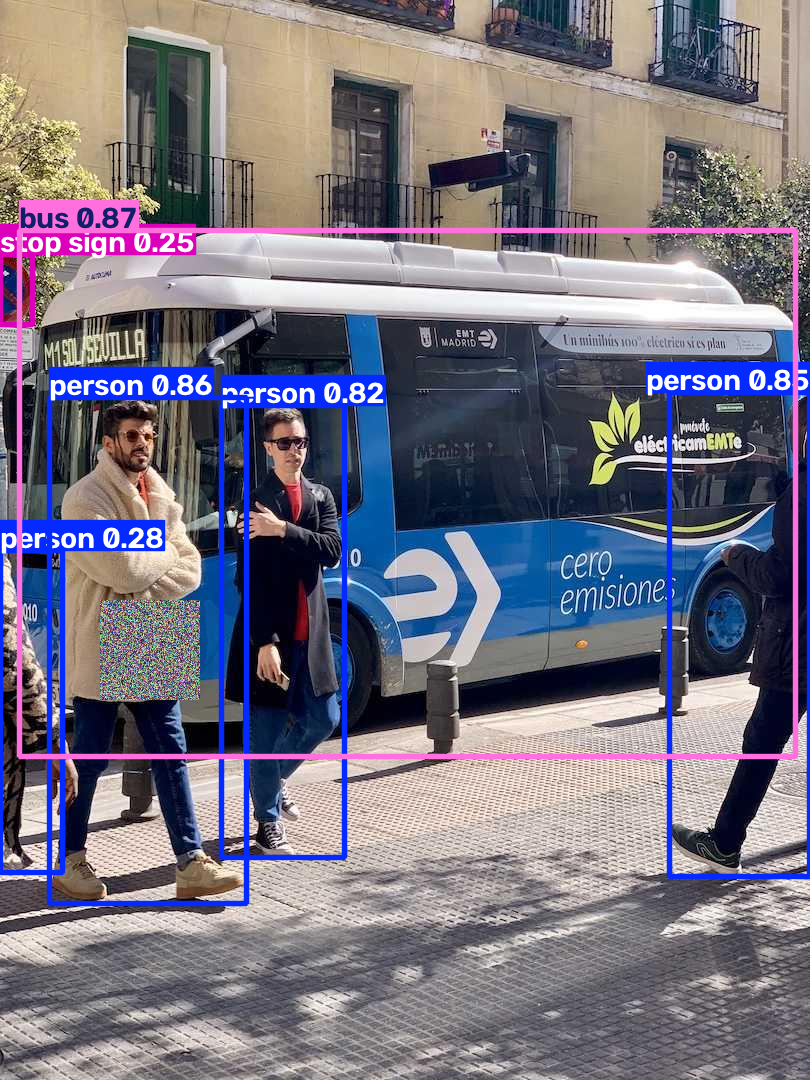


--- Détections YOLO après application du patch ---
Objet détecté : bus | Confiance : 0.87
Objet détecté : person | Confiance : 0.86
Objet détecté : person | Confiance : 0.85
Objet détecté : person | Confiance : 0.82
Objet détecté : person | Confiance : 0.28
Objet détecté : stop sign | Confiance : 0.25


In [31]:
# Sauvegarde temporaire de l'image modifiée pour que YOLO puisse l'analyser
temp_path = "temp_patched_image.jpg"
modified_image.save(temp_path)

# Prédiction YOLO sur l'image modifiée
patched_results = model(temp_path)

# Affichage des résultats avec les bounding boxes
patched_results[0].show()

# Extraction textuelle des détections (Classes et Scores de confiance)
print("\n--- Détections YOLO après application du patch ---")
for box in patched_results[0].boxes:
    cls_id = int(box.cls[0].item())
    cls_name = model.names[cls_id]
    conf = box.conf[0].item()
    print(f"Objet détecté : {cls_name} | Confiance : {conf:.2f}")

In [34]:
import torch.optim as optim
import torch.nn.functional as F

# 1. Redimensionnement propre de l'image de base en 640x640 (standard YOLOv8)
pil_img = Image.open(image_path).convert("RGB").resize((640, 640))
orig_tensor = transforms.ToTensor()(pil_img).unsqueeze(0).to(device)

# 2. Initialisation du patch sur le bon device
adversarial_patch = torch.rand(3, patch_h, patch_w, device=device, requires_grad=True)
optimizer = optim.Adam([adversarial_patch], lr=0.05)
num_iterations = 40

print("🚀 Début de l'optimisation du patch adversarial (640x640)...")

for iteration in range(num_iterations):
    optimizer.zero_grad()

    # A. EOT (Expectation Over Transformation)
    noise = torch.randn_like(orig_tensor, device=device) * 0.02
    eot_img = torch.clamp(orig_tensor + noise, 0.0, 1.0)

    # B. Incrustation du patch (coordonnées adaptées au format 640x640)
    # Assurons-nous que x et y ne débordent pas de 640
    x_min = min(x, 640 - patch_w)
    y_min = min(y, 640 - patch_h)
    x_max, y_max = x_min + patch_w, y_min + patch_h

    patched_img = eot_img.clone()
    patched_img[:, :, y_min:y_max, x_min:x_max] = adversarial_patch

    # C. Passage dans le modèle interne (maintenant sans erreur de taille de concaténation)
    preds = model.model(patched_img)

    # D. Loss de dissimulation (minimiser les activations)
    if isinstance(preds, (list, tuple)):
        loss = torch.mean(preds[0]**2)
    else:
        loss = torch.mean(preds**2)

    # E. Rétropropagation
    loss.backward()
    optimizer.step()

    # F. Sécurité physique (valeurs entre 0 et 1)
    with torch.no_grad():
        adversarial_patch.clamp_(0.0, 1.0)

    if (iteration + 1) % 10 == 0 or iteration == 0:
        print(f"Itération {iteration + 1}/{num_iterations} - Loss : {loss.item():.4f}")

print("✨ Optimisation terminée avec succès !")

🚀 Début de l'optimisation du patch adversarial (640x640)...
Itération 1/40 - Loss : 3491.3357
Itération 10/40 - Loss : 3473.9900
Itération 20/40 - Loss : 3469.7102
Itération 30/40 - Loss : 3467.1580
Itération 40/40 - Loss : 3466.5959
✨ Optimisation terminée avec succès !



image 1/1 /content/temp_optimized_patched.jpg: 640x640 4 persons, 1 bus, 7.8ms
Speed: 0.9ms preprocess, 7.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


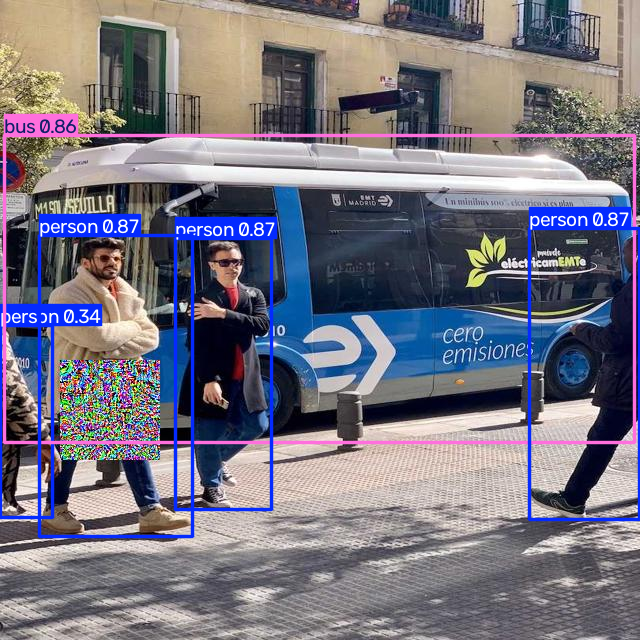


--- Détections après optimisation du patch adversarial ---
-> Objet : person | Confiance : 0.87
-> Objet : person | Confiance : 0.87
-> Objet : person | Confiance : 0.87
-> Objet : bus | Confiance : 0.86
-> Objet : person | Confiance : 0.34


In [37]:
# Application finale du patch optimisé sur l'image 640x640
final_patched_img = orig_tensor.clone()
scale_x=0.6
scale_y=0.6
x_scaled = int(x * scale_x)
y_scaled = int(y * scale_y)
x_min = min(x_scaled, 640 - patch_w)
y_min = min(y_scaled, 640 - patch_h)
x_max, y_max = x_min + patch_w, y_min + patch_h

final_patched_img[:, :, y_min:y_max, x_min:x_max] = adversarial_patch

# Conversion en image PIL
to_pil = transforms.ToPILImage()
result_pil_img = to_pil(final_patched_img.squeeze(0).cpu())

# Sauvegarde temporaire pour YOLO
temp_optimized_path = "temp_optimized_patched.jpg"
result_pil_img.save(temp_optimized_path)

# Prédiction YOLO classique sur l'image finale
opt_results = model(temp_optimized_path)
opt_results[0].show()

# Affichage textuel des boîtes et scores mis à jour
print("\n--- Détections après optimisation du patch adversarial ---")
if len(opt_results[0].boxes) == 0:
    print("🎯 Succès total ! Le patch a complètement aveuglé le modèle !")
else:
    for box in opt_results[0].boxes:
        cls_id = int(box.cls[0].item())
        cls_name = model.names[cls_id]
        conf = box.conf[0].item()
        print(f"-> Objet : {cls_name} | Confiance : {conf:.2f}")